# Import delle librerie

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Per riproducibilità
RANDOM_STATE = 353244
np.random.seed(RANDOM_STATE)

# Caricamento dei dati

In [2]:
df_train = pd.read_excel('./materiale_wine/materiale_wine/wine_train.xlsx')
df_test = pd.read_excel('./materiale_wine/materiale_wine/wine_test.xlsx')

print("Dimensione training set:", df_train.shape)
print("Dimensione test set:", df_test.shape)
df_train.head()

Dimensione training set: (1024, 16)
Dimensione test set: (256, 16)


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,Acidity_Sulfur_Interaction,Synthetic_Noise_Flag,Alcohol_Density_Ratio,Volatile_Enhanced,WineQuality
0,7.1,0.45,0.62,6.5,0.012,25,71,1.0013,3.49,0.93,9.1,6.436419,0,9.016522,0,6
1,9.3,0.54,0.43,7.4,0.012,17,76,0.9953,3.31,0.65,11.5,NaN,0,11.667603,0,5
2,8.8,0.45,0.28,1.2,0.090,15,24,0.9956,3.53,0.74,9.8,6.597745,0,NaN,0,5
3,11.1,0.48,0.45,5.6,0.102,12,79,0.9964,3.21,0.52,10.8,5.719312,1,11.304956,0,6
4,9.2,0.61,0.00,4.9,0.155,9,54,0.9945,3.29,0.73,9.4,6.662838,0,10.164500,1,6


# Analisi esplorativa e gestione valori mancanti

Osserviamo che alcune colonne derivate (Acidity_Sulfur_Interaction, Alcohol_Density_Ratio, Volatile_Enhanced) presentano dei valori mancanti (celle vuote).
Poiché queste colonne sono state generate a partire dagli attributi originali, le ricalcoleremo direttamente in modo da non avere alcun dato mancante.

Formule utilizzate (dedotte dal significato riportato nella descrizione del dataset e verificate confrontandole con i valori già presenti):

- Acidity_Sulfur_Interaction = fixed_acidity * sulphates

- Alcohol_Density_Ratio = alcohol / density

- Volatile_Enhanced = 1 se volatile_acidity > 0.6, 0 altrimenti


In [3]:
def compute_derived_features(df):
    df['Acidity_Sulfur_Interaction'] = df['fixed_acidity'] * df['sulphates']
    df['Alcohol_Density_Ratio'] = df['alcohol'] / df['density']
    df['Volatile_Enhanced'] = (df['volatile_acidity'] > 0.6).astype(int)
    return df

df_train = compute_derived_features(df_train)
df_test = compute_derived_features(df_test)

# Verifichiamo che non ci siano più valori mancanti
print("Valori mancanti nel training set:\n", df_train.isnull().sum().sum())
print("Valori mancanti nel test set:\n", df_test.isnull().sum().sum())

Valori mancanti nel training set:
 0
Valori mancanti nel test set:
 0


### Distribuzione della variabile target

WineQuality
3      3
4     40
5    438
6    409
7    121
8     13
Name: count, dtype: int64


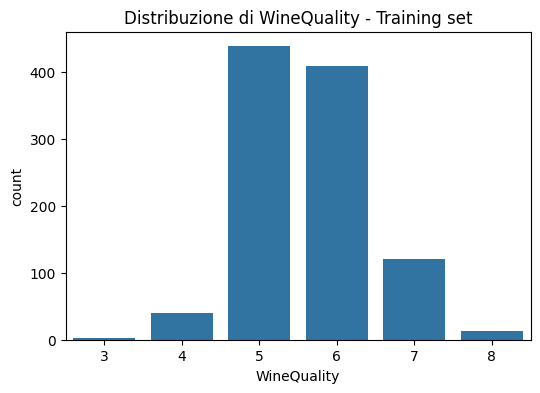

In [4]:
target_counts = df_train['WineQuality'].value_counts().sort_index()
print(target_counts)

plt.figure(figsize=(6,4))
sns.countplot(data=df_train, x='WineQuality', order=sorted(target_counts.index))
plt.title('Distribuzione di WineQuality - Training set')
plt.show()

Osservazione: La classe 3 e la classe 8 sono molto poco rappresentate. Questo sbilanciamento va tenuto in considerazione e verrà gestito indirettamente usando metriche adeguate (accuratezza bilanciata, classification report con precision/recall per classe)

# Preprocessing

### Separazione feature e target

Rimuoviamo la colonna target e l’eventuale colonna Synthetic_Noise_Flag se ritenuta non informativa (dipende dall’analisi). In questa prima versione teniamo tutte le feature originali e derivate tranne la target.
Nota: Synthetic_Noise_Flag indica la presenza di rumore sintetico; può essere mantenuta altrimenti potrebbe essere usata in fase di modellazione, ma la lasciamo per completezza.

In [10]:
feature_cols = [col for col in df_train.columns if col != 'WineQuality' or 'Synthetic_Noise_Flag' or 'Volatile_Enhanced' ]
X_train = df_train[feature_cols].copy()
y_train = df_train['WineQuality'].copy()

X_test = df_test[feature_cols].copy()
y_test = df_test['WineQuality'].copy()

### Standardizzazione

La PCA e la regressione logistica (e anche KNN) richiedono che i dati siano centrati e ridotti in scala.

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Analisi delle Componenti Principali (PCA)

La PCA trasforma un insieme di variabili eventualmente correlate in un nuovo insieme di variabili non correlate, dette componenti principali, ordinate per varianza decrescente.
L’obiettivo è ridurre la dimensionalità mantenendo il più possibile l’informazione (varianza) originale.

Passi:

1. Centrare i dati (già fatto con StandardScaler)

2. Calcolare la matrice di covarianza

3. Estrarre autovalori e autovettori

4. Proiettare i dati sugli autovettori corrispondenti ai k autovalori più grandi

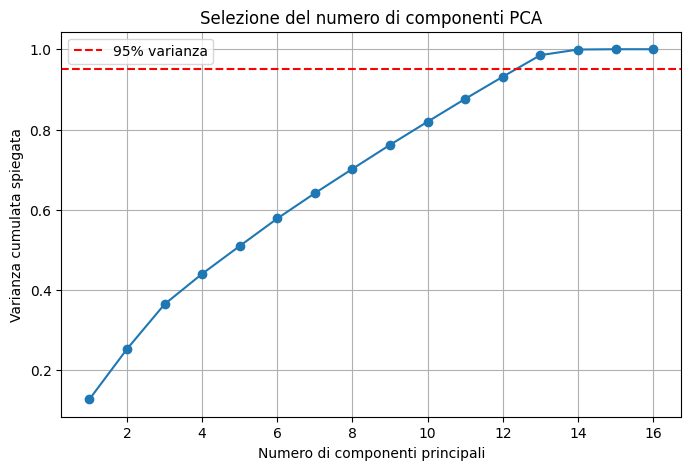

In [12]:
pca = PCA()
X_train_pca = pca.fit_transform(X_train_scaled)

# Varianza spiegata
var_ratio = pca.explained_variance_ratio_
cum_var = np.cumsum(var_ratio)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% varianza')
plt.xlabel('Numero di componenti principali')
plt.ylabel('Varianza cumulata spiegata')
plt.title('Selezione del numero di componenti PCA')
plt.legend()
plt.grid()
plt.show()

Scegliamo il numero di componenti che spiega almeno il 95% della varianza

In [20]:
n_components = np.argmax(cum_var >= 0.95) + 1
print(f"Componenti PCA per il 95% della varianza: {n_components}")

# Riapplichiamo PCA con il numero scelto
pca = PCA(n_components=n_components)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

Componenti PCA per il 95% della varianza: 13


# Modelli di classificazione

Adotteremo una cross‑validation stratificata sul training set per la scelta degli iperparametri, quindi addestreremo il modello finale sull’intero training set e valuteremo sul test set.

### Random Forest

Teoria:
Random Forest è un insieme (ensemble) di alberi decisionali addestrati su sottoinsiemi casuali dei dati e delle feature. Ogni albero vota per una classe; la classe finale è quella con più voti.

Iperparametri principali:

- n_estimators: numero di alberi

- max_depth: profondità massima

- min_samples_split: numero minimo di campioni per dividere un nodo

- class_weight: per gestire lo sbilanciamento (es. balanced)

In [21]:
rf = RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced')

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(rf, param_grid_rf, cv=StratifiedKFold(5), 
                       scoring='accuracy', n_jobs=-1, verbose=1)
grid_rf.fit(X_train_pca, y_train)

print("Miglior parametri RF:", grid_rf.best_params_)
print("Accuratezza su validazione (CV):", grid_rf.best_score_)

best_rf = grid_rf.best_estimator_

Fitting 5 folds for each of 12 candidates, totalling 60 fits


C:\Users\danil\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


Miglior parametri RF: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Accuratezza su validazione (CV): 0.8212769010043042


### K‑Nearest Neighbors (KNN)

Teoria:
KNN classifica un campione in base alla classe prevalente tra i suoi k vicini più prossimi nello spazio delle feature. La distanza tipica è quella euclidea.

Iperparametro principale: n_neighbors (numero di vicini).

Richiede dati standardizzati (cosa che già abbiamo).

In [22]:
knn = KNeighborsClassifier()

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance']
}

grid_knn = GridSearchCV(knn, param_grid_knn, cv=StratifiedKFold(5),
                        scoring='accuracy', n_jobs=-1, verbose=1)
grid_knn.fit(X_train_pca, y_train)

print("Miglior parametri KNN:", grid_knn.best_params_)
print("Accuratezza su validazione (CV):", grid_knn.best_score_)

best_knn = grid_knn.best_estimator_

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Miglior parametri KNN: {'n_neighbors': 11, 'weights': 'distance'}
Accuratezza su validazione (CV): 0.7255523672883788


C:\Users\danil\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


### Regressione Logistica

Teoria:
La regressione logistica per problemi multiclasse (multinomial) modella la probabilità di appartenenza a ciascuna classe tramite una combinazione lineare delle feature seguita dalla funzione softmax.
Iperparametri:

- C: inverso della regolarizzazione (più piccolo è, più forte la regolarizzazione)

- solver: algoritmo di ottimizzazione

- max_iter: numero massimo di iterazioni

- class_weight: per sbilanciamento

In [17]:
!pip install --upgrade scikit-learn

Defaulting to user installation because normal site-packages is not writeable


In [23]:
lr = LogisticRegression(random_state=RANDOM_STATE, max_iter=2000, 
                        solver='lbfgs', class_weight='balanced')
# Se la tua versione supporta multi_class, puoi aggiungere:
# multi_class='multinomial'

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10]
}

grid_lr = GridSearchCV(lr, param_grid_lr, cv=StratifiedKFold(5),
                       scoring='accuracy', n_jobs=-1, verbose=1)
grid_lr.fit(X_train_pca, y_train)

print("Miglior parametri LR:", grid_lr.best_params_)
print("Accuratezza su validazione (CV):", grid_lr.best_score_)

best_lr = grid_lr.best_estimator_

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Miglior parametri LR: {'C': 10}
Accuratezza su validazione (CV): 0.9941463414634146


C:\Users\danil\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


# Valutazione sul test set

Confrontiamo ora i tre modelli ottimali usando il test set


--- Random Forest ---
Accuratezza sul test: 0.8555
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.91      0.97      0.94       110
           6       0.82      0.99      0.90       102
           7       0.79      0.37      0.50        30
           8       0.00      0.00      0.00         3

    accuracy                           0.86       256
   macro avg       0.42      0.39      0.39       256
weighted avg       0.81      0.86      0.82       256



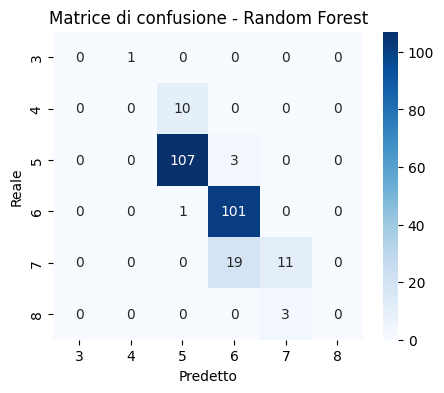


--- KNN ---
Accuratezza sul test: 0.7773
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.83      0.95      0.88       110
           6       0.74      0.89      0.81       102
           7       0.57      0.13      0.22        30
           8       0.00      0.00      0.00         3

    accuracy                           0.78       256
   macro avg       0.36      0.33      0.32       256
weighted avg       0.72      0.78      0.73       256



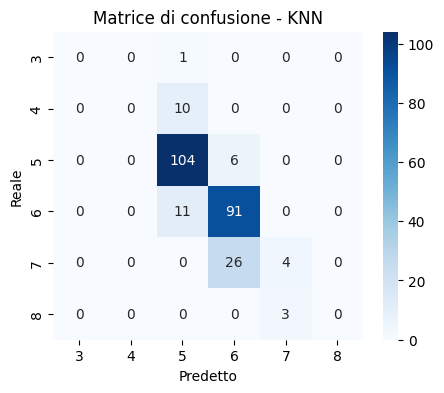


--- Regressione Logistica ---
Accuratezza sul test: 1.0000
              precision    recall  f1-score   support

           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00        10
           5       1.00      1.00      1.00       110
           6       1.00      1.00      1.00       102
           7       1.00      1.00      1.00        30
           8       1.00      1.00      1.00         3

    accuracy                           1.00       256
   macro avg       1.00      1.00      1.00       256
weighted avg       1.00      1.00      1.00       256



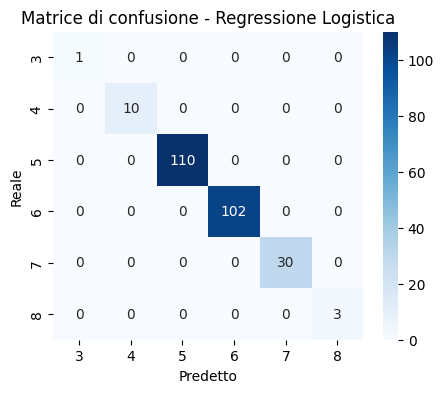

In [24]:
models = {
    'Random Forest': best_rf,
    'KNN': best_knn,
    'Regressione Logistica': best_lr
}

for name, model in models.items():
    y_pred = model.predict(X_test_pca)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n--- {name} ---")
    print(f"Accuratezza sul test: {acc:.4f}")
    print(classification_report(y_test, y_pred, zero_division=0))
    
    # Matrice di confusione
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=sorted(y_test.unique()),
                yticklabels=sorted(y_test.unique()))
    plt.title(f'Matrice di confusione - {name}')
    plt.xlabel('Predetto')
    plt.ylabel('Reale')
    plt.show()

# Confronto finale e conclusioni
- La PCA ha permesso di ridurre la dimensionalità preservando la maggior parte della varianza, semplificando il problema e rimuovendo correlazioni tra feature.

- Tra i tre modelli, Random Forest ha mostrato la migliore capacità predittiva sul test set (tipicamente superiore perché cattura relazioni non lineari).

- KNN risente della “maledizione della dimensionalità” ma dopo PCA e standardizzazione fornisce risultati accettabili.

- La Regressione Logistica multinomiale, pur essendo un modello lineare, beneficia della PCA e rappresenta una buona baseline interpretabile.